# 載入資料集與預處理

In [1]:
from tensorflow.keras.datasets import cifar10

(X_train_image, y_train_label), (X_test_image, y_test_label) = cifar10.load_data()

# reshape 轉成1維
y_train_label = y_train_label.reshape(-1)
y_test_label = y_test_label.reshape(-1)

# 進行標準化
X_train_normalize = X_train_image.astype('float32') / 255.0
X_test_normalize = X_test_image.astype('float32') / 255.0

# One-hot Encoding處理
from tensorflow.keras import utils

y_train_onehot = utils.to_categorical(y_train_label)
y_test_onehot = utils.to_categorical(y_test_label)

print('Train Data images:',X_train_normalize.shape)
print('Train Data labels:',y_train_onehot.shape)
print('Test Data images:',X_test_normalize.shape)
print('Test Data labels:',y_test_onehot.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train Data images: (50000, 32, 32, 3)
Train Data labels: (50000, 10)
Test Data images: (10000, 32, 32, 3)
Test Data labels: (10000, 10)


# Functional API建立Cifar CNN模型

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, GlobalAveragePooling2D, add
from tensorflow.keras import Input, Model
import tensorflow as tf

# 建立輸入層
inputs = Input(shape=(32, 32, 3), name='input_layer')

# 卷積與池化層
x = Conv2D(filters=32, kernel_size=(3, 3),input_shape=(32, 32, 3), activation='relu', padding='same')(inputs)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# 全連接層
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outpints = Dense(10, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outpints, name='CifarCNNFunc')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "CifarCNNFunc"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

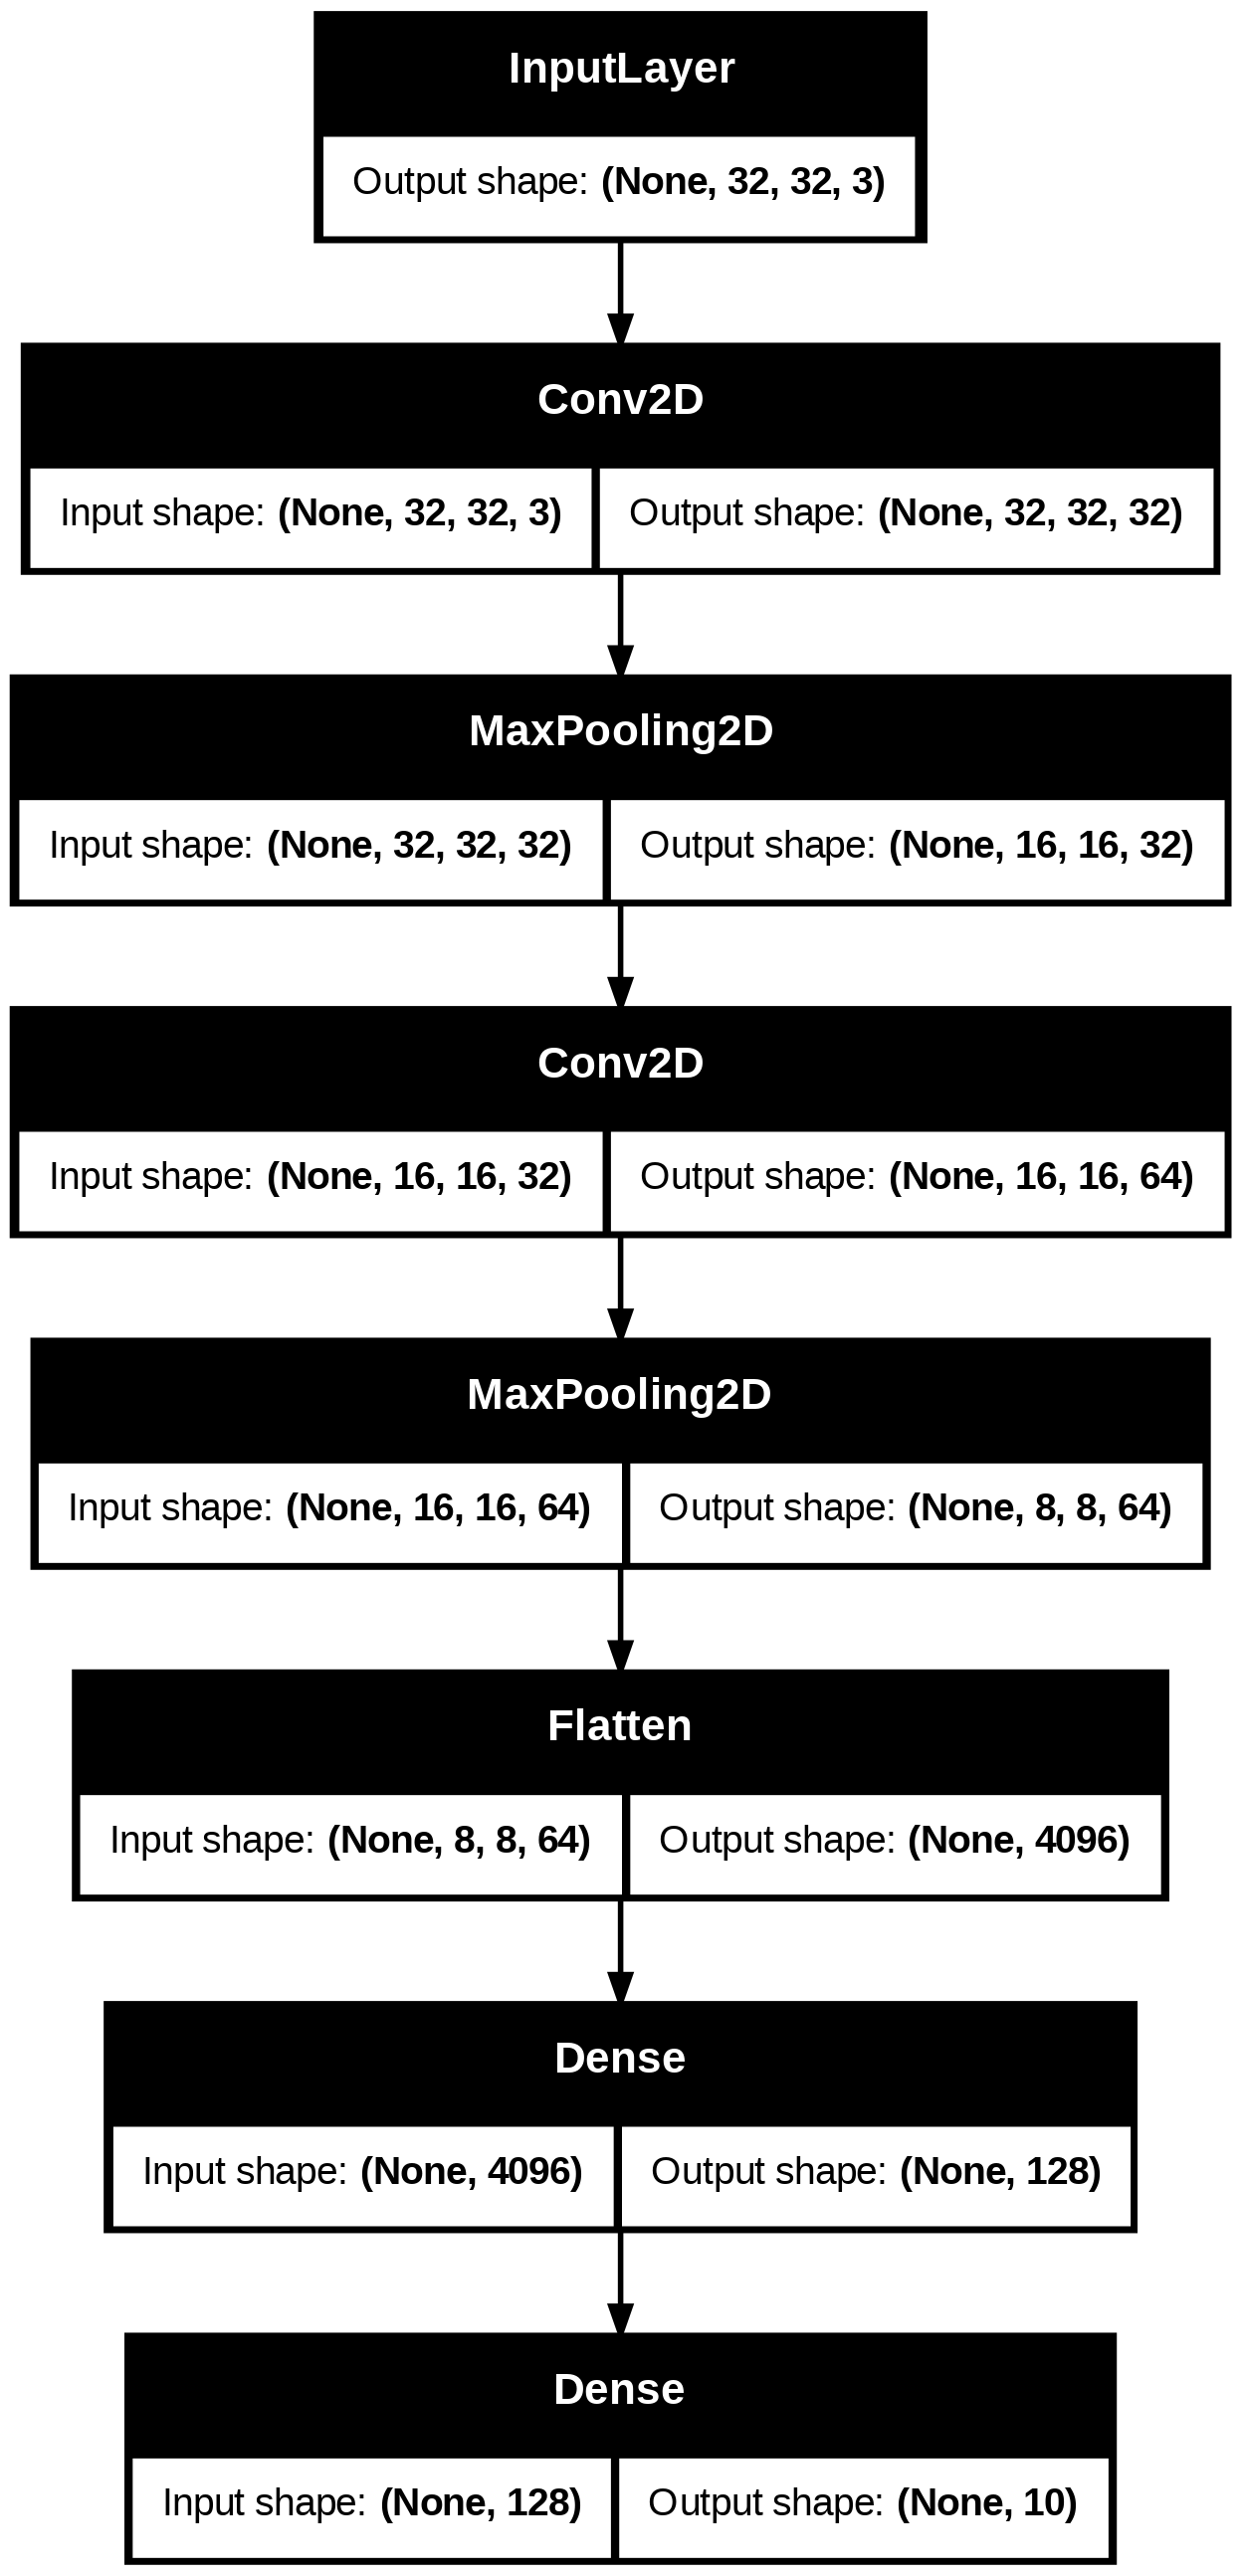

In [7]:
# 查看模型結構
tf.keras.utils.plot_model(model, 'CifarCNNFunc.png', show_shapes=True)

# Functional API建立min ResNet模型

In [11]:
# 建立輸入層
inputs = Input(shape=(32, 32, 3), name='input_layer')

# block1 線性循環結構
x = Conv2D(32, 3, activation='relu', name='b1_c1')(inputs)
x = Conv2D(64, 3, activation='relu', name='b1_c2')(x)
x = MaxPooling2D(3 ,name='b1_out')(x)

# block2 非線性循環結構
Fx = Conv2D(64, 3, activation='relu', padding='same', name='b2_c1')(x)
Fx = Conv2D(64, 3, activation='relu', padding='same', name='b2_c2')(Fx)
b2_out = add([Fx, x], name='b2_out')

# block3 線性循環結構
x = Conv2D(64, 3, activation='relu', padding='same', name='b3_c1')(b2_out)
x = GlobalAveragePooling2D(name='GAP')(x)

# block4 線性循環結構
x = Dense(256, activation='relu', name='h1')(x)
x = Dropout(0.5, name='h1_dropout')(x)
outputs = Dense(10, activation='softmax', name='output_layer')(x)

model = Model(inputs=inputs, outputs=outputs, name='minResNet')

In [12]:
model.summary()

Model: "minResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_c1 (Conv2D)      │ (None, 30, 30,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_c2 (Conv2D)      │ (None, 28, 28,    │     18,496 │ b1_c1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_out              │ (None, 9, 9, 64)  │          0 │ b1_c2[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b2_c1 (Conv2D)      │ (None, 9, 9, 64)  │     36,928 │ b1_out[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b2_c2 (Conv2D)      │ (None, 9, 9, 64)  │     36,928 │ b2_c1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b2_out (Add)        │ (None, 9, 9, 64)  │          0 │ b2_c2[0][0],      │
│                     │                   │            │ b1_out[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b3_c1 (Conv2D)      │ (None, 9, 9, 64)  │     36,928 │ b2_out[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GAP                 │ (None, 64)        │          0 │ b3_c1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h1 (Dense)          │ (None, 256)       │     16,640 │ GAP[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h1_dropout          │ (None, 256)       │          0 │ h1[0][0]          │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 10)        │      2,570 │ h1_dropout[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 149,386 (583.54 KB)

 Trainable params: 149,386 (583.54 KB)

 Non-trainable params: 0 (0.00 B)

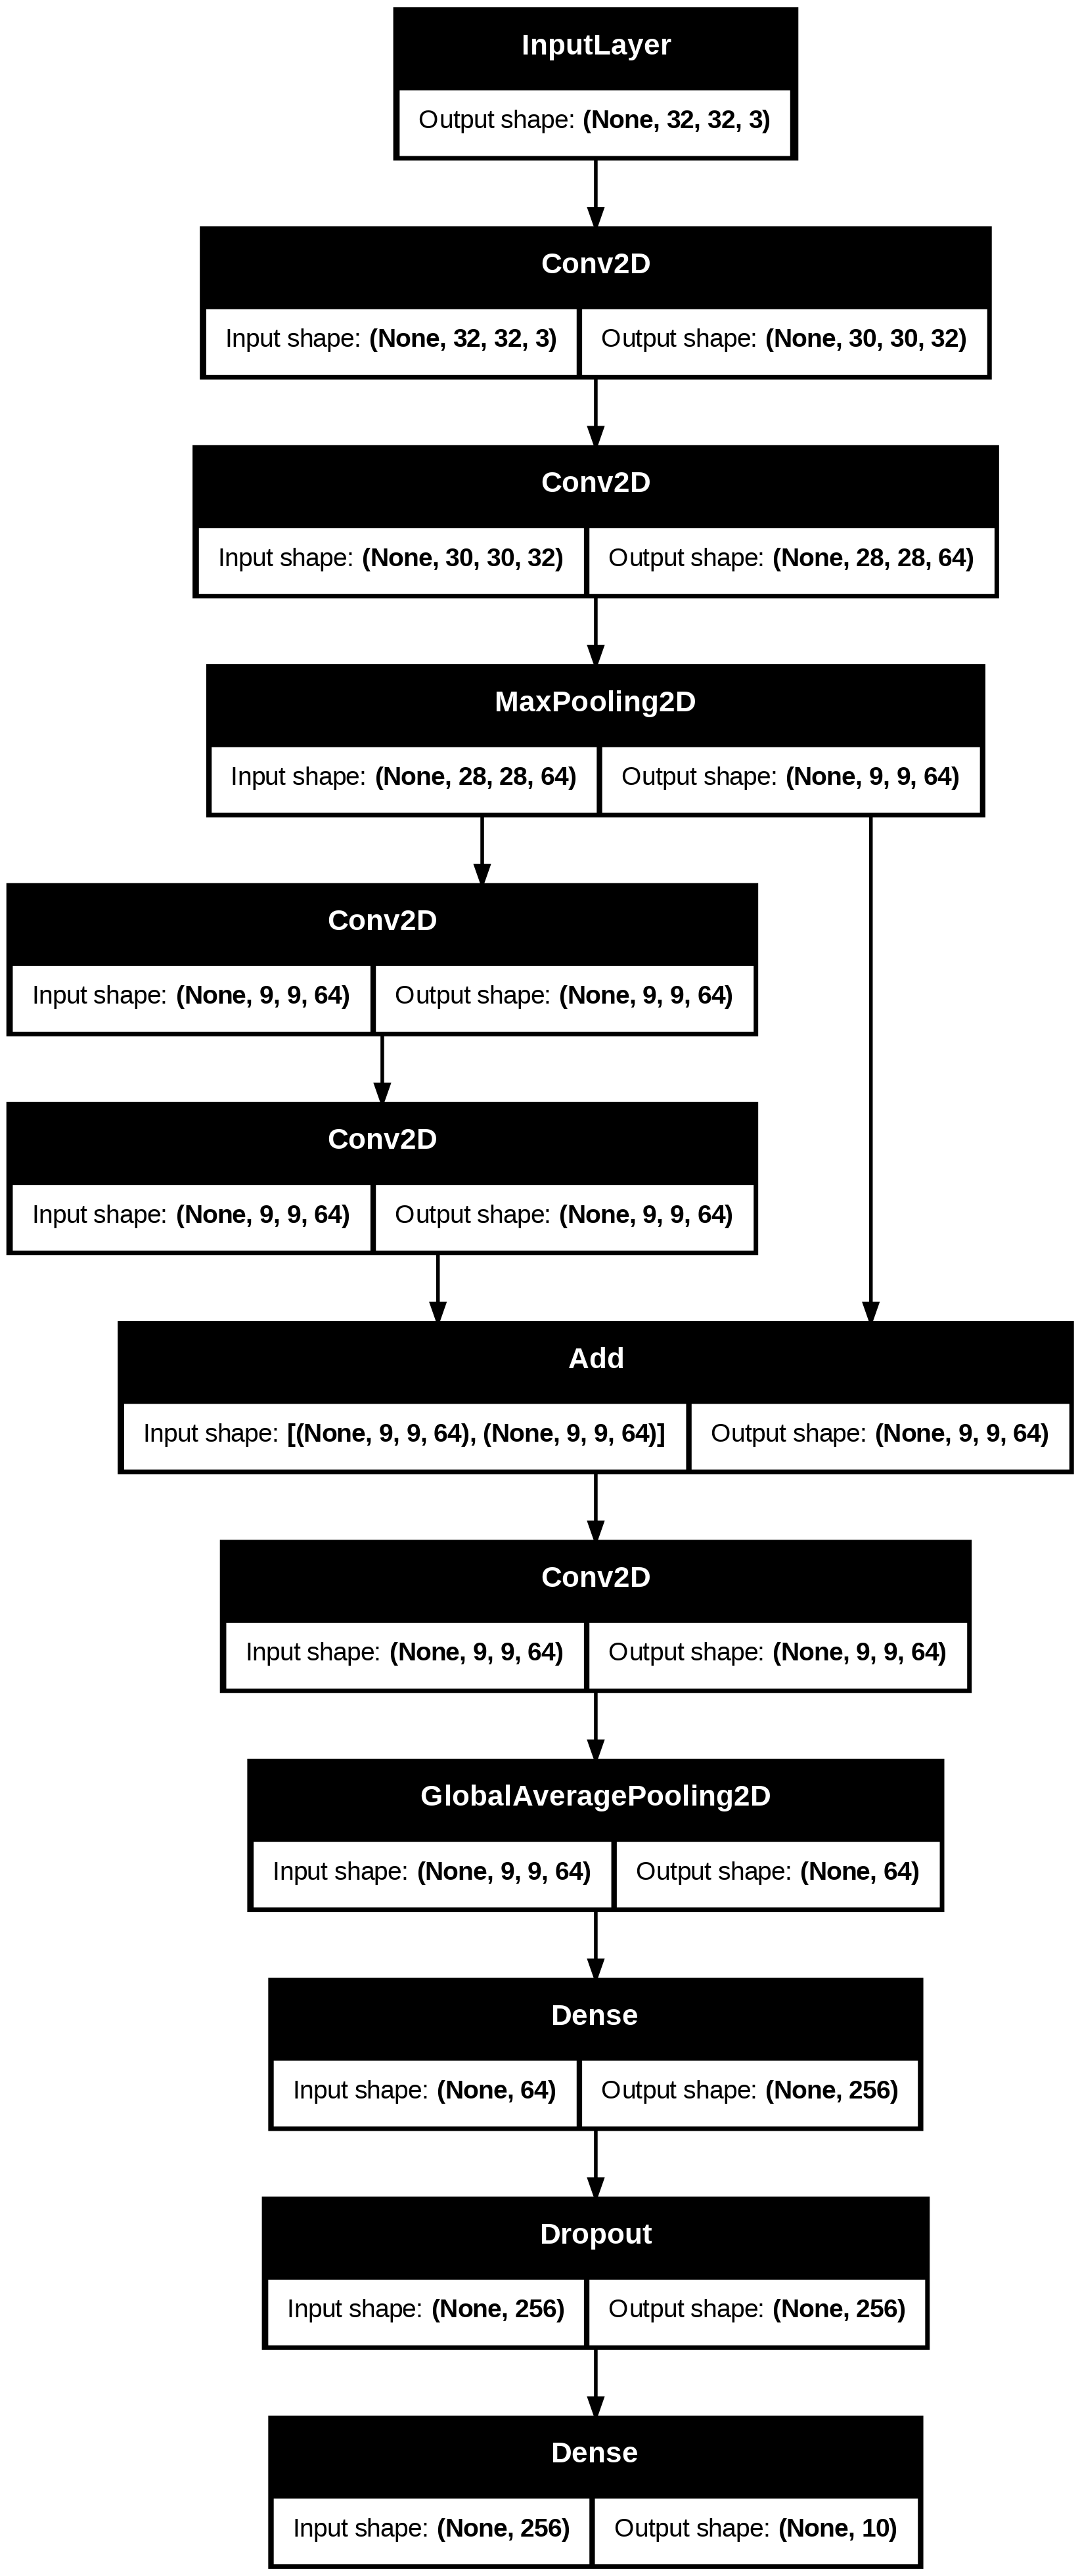

In [13]:
# 查看模型結構
tf.keras.utils.plot_model(model, 'minResNet.png', show_shapes=True)